# Lid-driven cavity flow

## Import Library

In [2]:
import numpy as np
import matplotlib.pyplot as plt

## Domain Setup

In [3]:
L = 1.0  # Length of the cavity
N = 129   # Number of grid points

dx = L / (N - 1)
dy = L / (N - 1)

Re = 100.0  # Reynolds number
U_lid = 1.0  # Lid velocity

Nu = U_lid * L / Re  # Kinematic viscosity

# Initial velocity and pressure fields
u = np.zeros((N, N)) 
v = np.zeros((N, N))
p = np.zeros((N, N))

x = np.linspace(0, L, N)
y = np.linspace(0, L, N)
X, Y = np.meshgrid(x, y)

safety_factor = 0.8

dt = safety_factor / (U_lid/dx + U_lid/dy + 4*Nu/dx**2)

CFL_x = U_lid * dt / dx
CFL_y = U_lid * dt / dy
r = Nu * dt / dx**2

print(f"dt       = {dt:.6f}")
print(f"CFL_x    = {CFL_x:.4f}")
print(f"CFL_y    = {CFL_y:.4f}")
print(f"r        = {r:.4f}")
print(f"Combined = {CFL_x + CFL_y + 4*r:.4f}  (must be ≤ 1)")

nt = 20000  # Number of time steps
T = nt * dt  # Total simulation time
print(f"Total simulation time T = {T:.4f}")

dt       = 0.000878
CFL_x    = 0.1124
CFL_y    = 0.1124
r        = 0.1438
Combined = 0.8000  (must be ≤ 1)
Total simulation time T = 17.5562


## Algorithm Per Time Step

## Apply boundary conditions to u, v

In [4]:
def apply_boundary_conditions(u, v):
    # Top lid — moves right at U_lid, no vertical velocity
    u[-1, :] = U_lid
    v[-1, :] = 0.0

    # bottom
    u[0,:]=0.0
    v[0,:]=0.0
    
    # left
    u[:,0]=0.0
    v[:,0]=0.0

    # right
    u[:,-1]=0.0
    v[:,-1]=0.0

    return u, v

## Momentum Predictor - Compute u*, v* (momentum without pressure)

In [5]:
def momentum_predictor(u, v, p, dx, dy, dt, Nu):
    un = u.copy()
    vn = v.copy()

    u_star = un.copy()
    v_star = vn.copy()

    # Neighbours of u, v - interior points only
    u_e = un[1:-1, 2:]   # u[i, j+1]
    u_w = un[1:-1, :-2]  # u[i, j-1]
    u_n = un[2:, 1:-1]   # u[i+1, j]
    u_s = un[:-2, 1:-1]  # u[i-1, j]

    v_e = vn[1:-1, 2:]   # v[i, j+1]
    v_w = vn[1:-1, :-2]  # v[i, j-1]
    v_n = vn[2:, 1:-1]   # v[i+1, j]
    v_s = vn[:-2, 1:-1]  # v[i-1, j]

    # Convection terms - Upwind scheme
    conv_u_x = np.maximum(un[1:-1, 1:-1], 0) * (un[1:-1, 1:-1] - u_w)/dx + np.minimum(un[1:-1, 1:-1], 0) * (u_e - un[1:-1, 1:-1])/dx
    conv_u_y = np.maximum(vn[1:-1, 1:-1], 0) * (un[1:-1, 1:-1] - u_s)/dy + np.minimum(vn[1:-1, 1:-1], 0) * (u_n - un[1:-1, 1:-1])/dy
    
    conv_v_x = np.maximum(un[1:-1, 1:-1], 0) * (vn[1:-1, 1:-1] - v_w)/dx + np.minimum(un[1:-1, 1:-1], 0) * (v_e - vn[1:-1, 1:-1])/dx
    conv_v_y = np.maximum(vn[1:-1, 1:-1], 0) * (vn[1:-1, 1:-1] - v_s)/dy + np.minimum(vn[1:-1, 1:-1], 0) * (v_n - vn[1:-1, 1:-1])/dy

    conv_u = conv_u_x + conv_u_y
    conv_v = conv_v_x + conv_v_y

    # Diffusion terms (central differences)
    diff_u = Nu * (u_e - 2*un[1:-1, 1:-1] + u_w) / dx**2 + Nu * (u_n - 2*un[1:-1, 1:-1] + u_s) / dy**2
    diff_v = Nu * (v_n - 2*vn[1:-1, 1:-1] + v_s) / dy**2 + Nu * (v_e - 2*vn[1:-1, 1:-1] + v_w) / dx**2

    u_star[1:-1, 1:-1] = un[1:-1, 1:-1] + dt * (diff_u - conv_u)
    v_star[1:-1, 1:-1] = vn[1:-1, 1:-1] + dt * (diff_v - conv_v)

    return u_star, v_star

## Compute divergence b = ∇·u*

In [6]:
# compute the divergence of the intermediate velocity field
def compute_divergence(u_star, v_star, dx, dy):
    div = (u_star[1:-1, 2:] - u_star[1:-1, :-2]) / (2*dx) + (v_star[2:, 1:-1] - v_star[:-2, 1:-1]) / (2*dy)
    return div

## Connector - Pressure Poisson Solver

In [7]:
def pressure_poisson_connector(u_star, v_star, p, dx, dy, dt, rho=1.0, max_iter=20000, tol=1e-6):
    # Solve the Poisson equation iteratively
    for it in range(max_iter):
        p_old = p.copy()

        # Neighbours of p - interior points only
        p_e = p_old[1:-1, 2:]   # p[i, j+1]
        p_w = p_old[1:-1, :-2]  # p[i, j-1]
        p_n = p_old[2:, 1:-1]   # p[i+1, j]
        p_s = p_old[:-2, 1:-1]  # p[i-1, j]

        div = compute_divergence(u_star, v_star, dx, dy)

        rhs = (rho / dt) * div

        # Jacobi update for pressure
        p[1:-1, 1:-1] = (p_e + p_w) * dy**2 + (p_n + p_s) * dx**2 - rhs * dx**2 * dy**2
        p[1:-1, 1:-1] /= (2 * (dx**2 + dy**2))

        # Boundary conditions for pressure (Neumann: dp/dn=0)
        p[0, :] = p[1, :]     # dp/dy=0 at bottom
        p[-1, :] = p[-2, :]   # dp/dy=0 at top
        p[:, 0] = p[:, 1]     # dp/dx=0 at left
        p[:, -1] = p[:, -2]   # dp/dx=0 at right

        p[1, 1] = 0.0  # Reference pressure point to avoid singularity

        # Check for convergence - max-norm (per-point). tol is tighter than the
        # old L2-norm default (1e-4) because L2-over-domain implicitly required
        # ~tol/sqrt(n_interior_points) per point -- about 7.9e-7 here -- so 1e-6
        # preserves a comparable depth of convergence in the pressure solve.
        if np.max(np.abs(p - p_old)) < tol:
            break
    else:
        print("Pressure Poisson did not converge within the maximum iterations.")
    
    return p

## Correct: u = u* - dt·∂p/∂x,  v = v* - dt·∂p/∂y

In [8]:
def velocity_corrector(u_star, v_star, p, dx, dy, dt, rho=1.0):
    u = u_star.copy()
    v = v_star.copy()

    # Neighbours of p - interior points only
    p_e = p[1:-1, 2:]   # p[i, j+1]
    p_w = p[1:-1, :-2]  # p[i, j-1]
    p_n = p[2:, 1:-1]   # p[i+1, j]
    p_s = p[:-2, 1:-1]  # p[i-1, j]

    u[1:-1, 1:-1] = u_star[1:-1, 1:-1] - (dt/rho) * (p_e - p_w) / (2*dx)
    v[1:-1, 1:-1] = v_star[1:-1, 1:-1] - (dt/rho) * (p_n - p_s) / (2*dy)

    return u, v

## Track ${max|u^{n+1} - u^n|}$ for steady state convergence

In [9]:
def check_convergence(u, v, u_old, v_old, tol=1e-6):
    # Max-norm, matching the printed residual metric. tol is tighter than the
    # old L2-norm default (1e-4) because L2-over-domain implicitly required
    # ~tol/sqrt(n_interior_points) per point -- about 7.9e-7 here -- so 1e-6
    # preserves a comparable depth of convergence to steady state.
    du = np.max(np.abs(u - u_old))
    dv = np.max(np.abs(v - v_old))
    return du < tol and dv < tol

## Main Loop

In [10]:
residual_history = []
u_history = []
v_history = []
p_history = []

for n in range(nt):
    u_old = u.copy()
    v_old = v.copy()
    p_old = p.copy()

    u_old, v_old = apply_boundary_conditions(u_old, v_old)
    u_star, v_star = momentum_predictor(u_old, v_old, p_old, dx, dy, dt, Nu)
    p = pressure_poisson_connector(u_star, v_star, p_old, dx, dy, dt)
    u, v = velocity_corrector(u_star, v_star, p, dx, dy, dt)

    u, v = apply_boundary_conditions(u, v)

    u_history.append(u.copy())
    v_history.append(v.copy())
    p_history.append(p.copy())

    residual = np.max(np.abs(u - u_old))
    residual_history.append(residual)
    if n % 100 == 0:
        print(f"Step {n:4d} | residual = {residual:.2e}")
        
    if check_convergence(u, v, u_old, v_old):
        print(f"Converged at step {n}.")
        break

else:    print("Did not converge within the maximum time steps.")

Pressure Poisson did not converge within the maximum iterations.
Step    0 | residual = 1.43e-01
Pressure Poisson did not converge within the maximum iterations.
Pressure Poisson did not converge within the maximum iterations.
Pressure Poisson did not converge within the maximum iterations.
Pressure Poisson did not converge within the maximum iterations.
Pressure Poisson did not converge within the maximum iterations.
Pressure Poisson did not converge within the maximum iterations.
Pressure Poisson did not converge within the maximum iterations.
Pressure Poisson did not converge within the maximum iterations.
Step  100 | residual = 2.24e-03
Step  200 | residual = 1.11e-03
Step  300 | residual = 7.34e-04
Step  400 | residual = 5.48e-04
Step  500 | residual = 4.33e-04
Step  600 | residual = 3.54e-04
Step  700 | residual = 2.97e-04
Step  800 | residual = 2.53e-04
Step  900 | residual = 2.19e-04
Step 1000 | residual = 1.91e-04
Step 1100 | residual = 1.68e-04
Step 1200 | residual = 1.49e-04

## Result Visualization

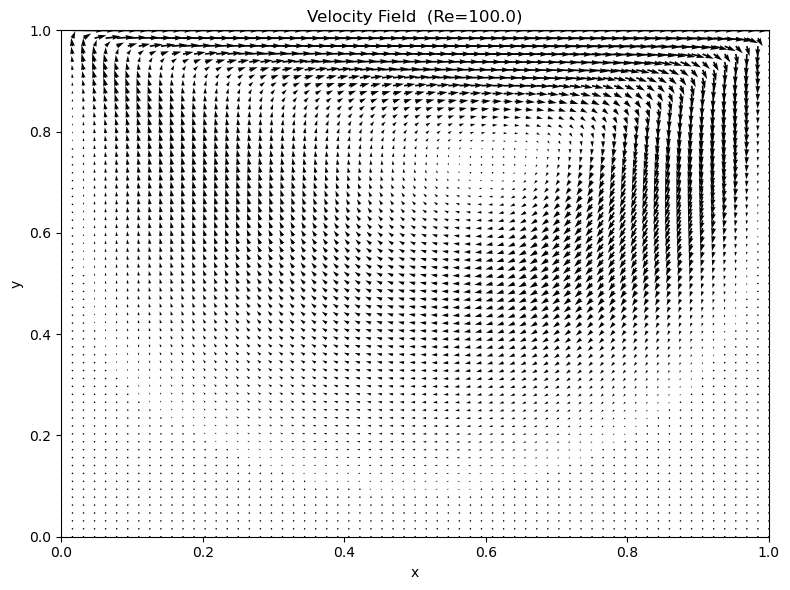

In [11]:
# Velocity Field — subsampled quiver
step = 2
plt.figure(figsize=(8, 6))
plt.title(f"Velocity Field  (Re={Re})")
plt.quiver(X[::step, ::step], Y[::step, ::step],
           u[::step, ::step], v[::step, ::step])
plt.xlabel('x'); plt.ylabel('y')
plt.xlim(0, L); plt.ylim(0, L)
plt.tight_layout()
plt.show()

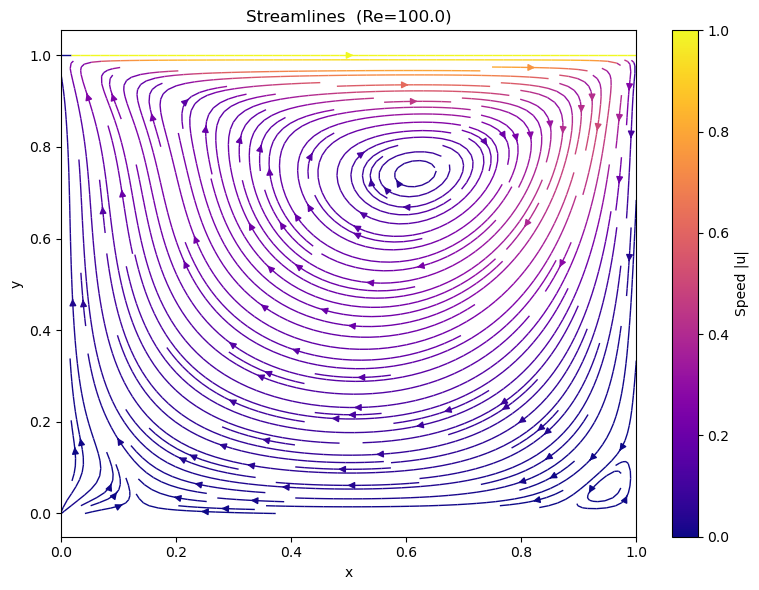

In [12]:
# Streamlines — primary vortex and corner vortices
speed = np.sqrt(u**2 + v**2)
plt.figure(figsize=(8, 6))
plt.title(f"Streamlines  (Re={Re})")
plt.streamplot(x, y, u, v, density=2, color=speed, cmap='plasma', linewidth=1)
plt.colorbar(label='Speed |u|')
plt.xlabel('x'); plt.ylabel('y')
plt.tight_layout()
plt.show()

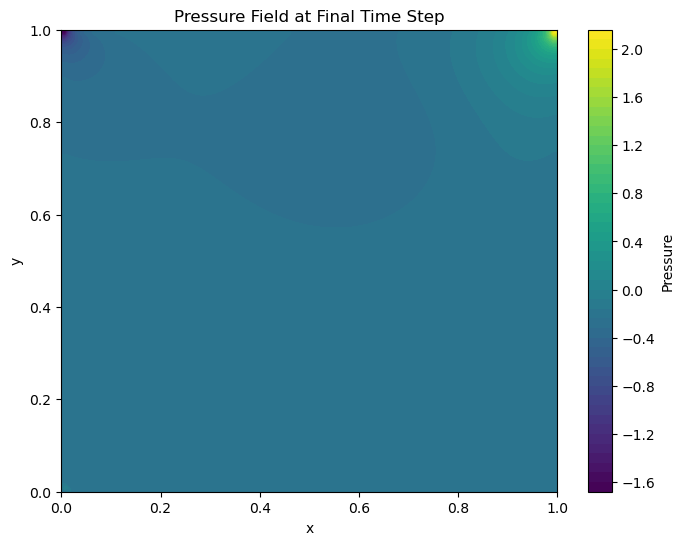

In [13]:
# Pressure Field Visualization
plt.figure(figsize=(8, 6))
plt.title("Pressure Field at Final Time Step")
plt.contourf(X, Y, p, levels=50, cmap='viridis')
plt.colorbar(label='Pressure')
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(0, L)
plt.ylim(0, L)
plt.show()

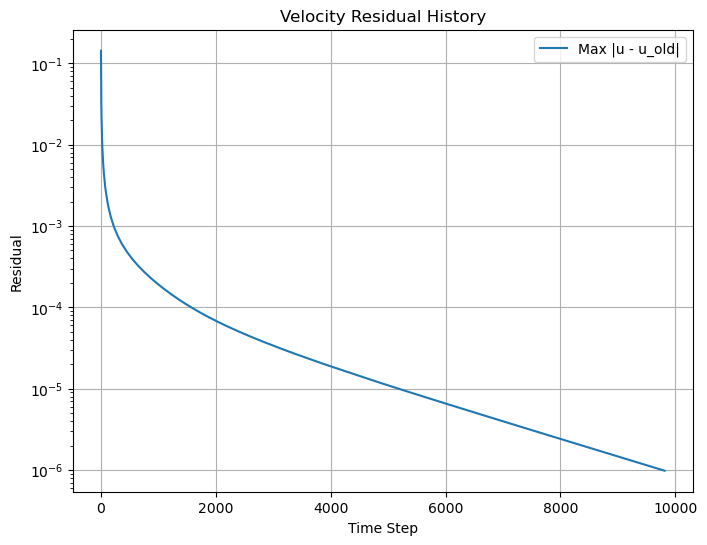

In [14]:
# Velocity Residual Plot
plt.figure(figsize=(8, 6))
plt.title("Velocity Residual History")
plt.semilogy(residual_history, label='Max |u - u_old|')
plt.xlabel('Time Step')
plt.ylabel('Residual')
plt.grid()
plt.legend()
plt.show()

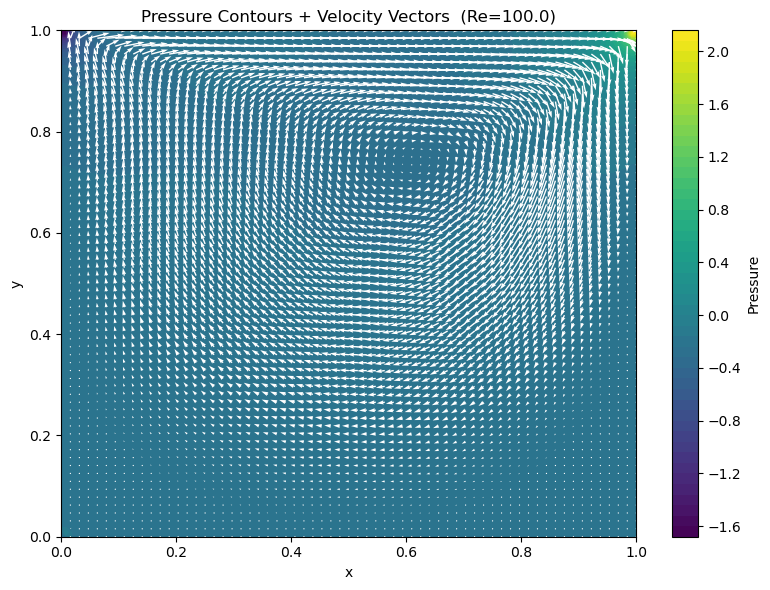

In [15]:
# Pressure contours + subsampled velocity vectors
step = 2
plt.figure(figsize=(8, 6))
plt.title(f"Pressure Contours + Velocity Vectors  (Re={Re})")
plt.contourf(X, Y, p, levels=50, cmap='viridis')
plt.colorbar(label='Pressure')
plt.quiver(X[::step, ::step], Y[::step, ::step],
           u[::step, ::step], v[::step, ::step],
           color='white', scale=10)
plt.xlabel('x'); plt.ylabel('y')
plt.tight_layout()
plt.show()

## Validation: Ghia et al. (1982) Benchmark

Compare centerline velocity profiles against the landmark paper:
**Ghia, Ghia & Shin (1982)** — *High-Re solutions for incompressible flow using the Navier-Stokes equations and a multigrid method*

- **u along x = 0.5** (vertical centerline): captures primary vortex strength
- **v along y = 0.5** (horizontal centerline): captures left/right recirculation

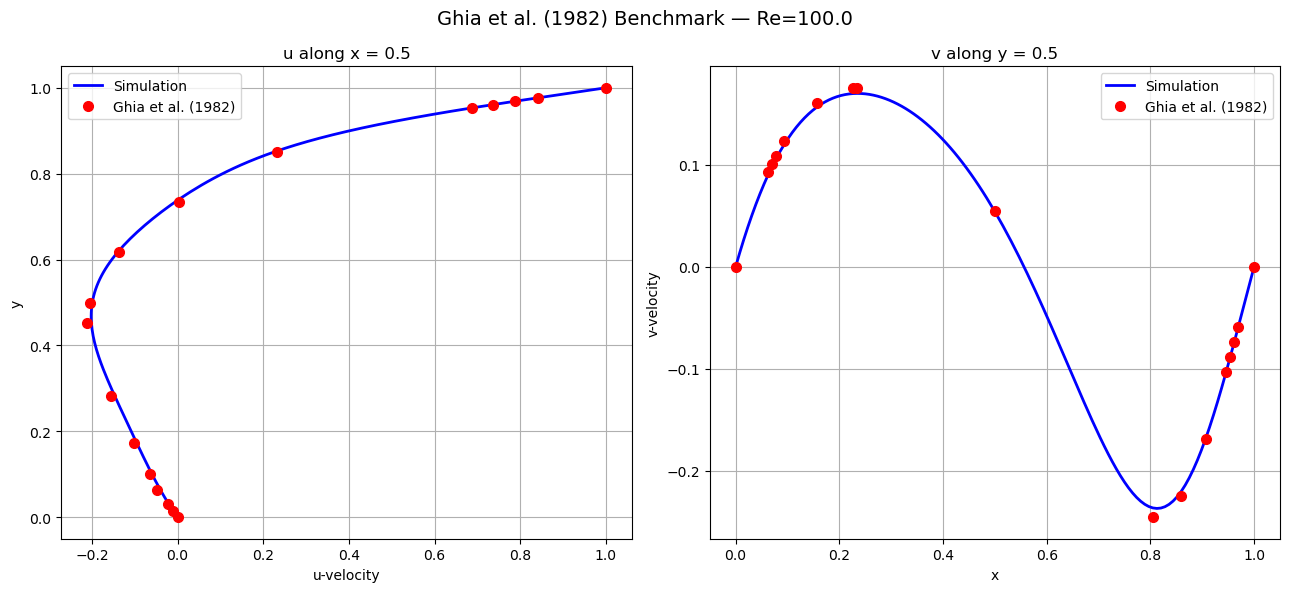

In [16]:
# Ghia et al. (1982) Re=100 benchmark data
ghia_y = [0.0000, 0.0156, 0.0313, 0.0625, 0.1016, 0.1719, 0.2813, 0.4531,
          0.5000, 0.6172, 0.7344, 0.8516, 0.9531, 0.9609, 0.9688, 0.9766, 1.0000]
ghia_u = [0.00000, -0.01160, -0.02347, -0.04775, -0.06434, -0.10150, -0.15662, -0.21090,
          -0.20581, -0.13641,  0.00332,  0.23151,  0.68717,  0.73722,  0.78871,  0.84123, 1.00000]

ghia_x = [0.0000, 0.0625, 0.0703, 0.0781, 0.0938, 0.1563, 0.2266, 0.2344,
          0.5000, 0.8047, 0.8594, 0.9063, 0.9453, 0.9531, 0.9609, 0.9688, 1.0000]
ghia_v = [0.00000,  0.09233,  0.10091,  0.10890,  0.12317,  0.16077,  0.17507,  0.17527,
          0.05454, -0.24533, -0.22445, -0.16914, -0.10313, -0.08864, -0.07391, -0.05906, 0.00000]

mid = N // 2  # N=129 points (N-1=128 cells, even) -> mid*dx = 0.5 exactly

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle(f"Ghia et al. (1982) Benchmark — Re={Re}", fontsize=14)

# u along vertical centerline (x = 0.5)
ax1.plot(u[:, mid], y, "-b", linewidth=2, label="Simulation")
ax1.plot(ghia_u, ghia_y, "ro", markersize=7, label="Ghia et al. (1982)")
ax1.set_xlabel("u-velocity"); ax1.set_ylabel("y")
ax1.set_title("u along x = 0.5")
ax1.legend(); ax1.grid(True)

# v along horizontal centerline (y = 0.5)
ax2.plot(x, v[mid, :], "-b", linewidth=2, label="Simulation")
ax2.plot(ghia_x, ghia_v, "ro", markersize=7, label="Ghia et al. (1982)")
ax2.set_xlabel("x"); ax2.set_ylabel("v-velocity")
ax2.set_title("v along y = 0.5")
ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.show()

In [17]:
from scipy.interpolate import interp1d

# Quantitative error vs Ghia (cubic-interpolate the simulation profile onto
# the Ghia tabulation points, same methodology used across all five solvers
# in this study so results are directly comparable)
interp_u = interp1d(y, u[:, mid], kind='cubic')
interp_v = interp1d(x, v[mid, :], kind='cubic')
err_u = np.max(np.abs(interp_u(ghia_y) - np.array(ghia_u)))
err_v = np.max(np.abs(interp_v(ghia_x) - np.array(ghia_v)))
print(f'Max |u - Ghia| along x=0.5: {err_u:.4f}')
print(f'Max |v - Ghia| along y=0.5: {err_v:.4f}')

Max |u - Ghia| along x=0.5: 0.0103
Max |v - Ghia| along y=0.5: 0.0091
